In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
ImageFile.LOAD_TRUNCATED_IMAGES = False

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-05-09 11:42:52.041653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778326972.290866      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778326972.367922      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778326972.925538      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778326972.925576      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778326972.925579      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Set Dataset Path

In [2]:
def locate_brain_tumor_dataset():
    input_root = Path("/kaggle/input/datasets/aakritirimal/brain-tumor-classification")
    for folder in input_root.rglob("*"):
        if folder.is_dir() and (folder / "train").exists() and (folder / "test").exists():
            return folder
    raise FileNotFoundError("Could not find dataset folder containing train and test directories.")

DATASET_ROOT = locate_brain_tumor_dataset()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

CLASS_DISPLAY_NAMES = {
    "glioma_tumor": "Glioma Tumor",
    "meningioma_tumor": "Meningioma Tumor",
    "normal": "Normal",
    "pituitary_tumor": "Pituitary Tumor",
}

print("Dataset root:", DATASET_ROOT)
print("Train folder:", TRAIN_DIR)
print("Test folder:", TEST_DIR)

Dataset root: /kaggle/input/datasets/aakritirimal/brain-tumor-classification/Brain Tumor Classifcation
Train folder: /kaggle/input/datasets/aakritirimal/brain-tumor-classification/Brain Tumor Classifcation/train
Test folder: /kaggle/input/datasets/aakritirimal/brain-tumor-classification/Brain Tumor Classifcation/test


Collect Image Records

In [4]:
def build_image_index(train_dir, test_dir):
    records = []
    for split_name, split_dir in [("train", train_dir), ("test", test_dir)]:
        for class_folder in sorted(split_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            for image_path in sorted(class_folder.glob("*")):
                if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    records.append({
                        "file_path": str(image_path),
                        "split": split_name,
                        "class_name": class_folder.name,
                        "class_display": CLASS_DISPLAY_NAMES.get(class_folder.name, class_folder.name),
                    })
    return pd.DataFrame(records)

image_records = build_image_index(TRAIN_DIR, TEST_DIR)
display(image_records.head())
print("Total image files found:", len(image_records))

,file_path,split,class_name,class_display
0,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor
1,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor
2,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor
3,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor
4,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor


Total image files found: 3096


Check Corrupted Images

In [6]:
def can_open_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.load()
        return True
    except Exception:
        return False

image_records["readable"] = image_records["file_path"].apply(can_open_image)
clean_df = image_records[image_records["readable"]].copy().reset_index(drop=True)
bad_df = image_records[~image_records["readable"]].copy().reset_index(drop=True)

print("Total files found:", len(image_records))
print("Corrupted files removed:", len(bad_df))
print("Readable files used:", len(clean_df))
display(bad_df.head(10))

if len(image_records) == 3096 and len(bad_df) == 28 and len(clean_df) == 3068:
    print("Dataset check : 3,096 total, 28 corrupted, 3,068 readable.")
else:
    print("Dataset count differs from the expected output.")

Total files found: 3096
Corrupted files removed: 28
Readable files used: 3068


,file_path,split,class_name,class_display,readable
0,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
1,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
2,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
3,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
4,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
5,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
6,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,glioma_tumor,Glioma Tumor,False
7,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,meningioma_tumor,Meningioma Tumor,False
8,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,meningioma_tumor,Meningioma Tumor,False
9,/kaggle/input/datasets/aakritirimal/brain-tumo...,train,meningioma_tumor,Meningioma Tumor,False


Dataset check : 3,096 total, 28 corrupted, 3,068 readable.


Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

Data Understanding, Analysis, Visualization and Cleaning

What does the dataset represent? Provide a brief description.

The dataset represents MRI brain images for a four-class brain tumor classification problem. The classes are glioma tumor, meningioma tumor, pituitary tumor, and normal brain images. The task is important because image classification models can support medical image analysis by identifying patterns that may help with earlier diagnosis and screening support.

How many total images are in the dataset?

The dataset contains 3,096 image files in total. During image verification, 28 corrupted files are expected to be identified and excluded. Therefore, 3,068 readable images are used for analysis, training, validation, and testing.

What is the distribution of images across different classes?

In [7]:
class_distribution = (
    clean_df.groupby(["split", "class_display"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "class_display"])
)
display(class_distribution)

overall_class_distribution = (
    clean_df.groupby("class_display")
    .size()
    .reset_index(name="readable_total")
    .sort_values("class_display")
)
display(overall_class_distribution)

,split,class_display,count
0,test,Glioma Tumor,181
1,test,Meningioma Tumor,183
2,test,Normal,88
3,test,Pituitary Tumor,169
4,train,Glioma Tumor,713
5,train,Meningioma Tumor,723
6,train,Normal,343
7,train,Pituitary Tumor,668


,class_display,readable_total
0,Glioma Tumor,894
1,Meningioma Tumor,906
2,Normal,431
3,Pituitary Tumor,837


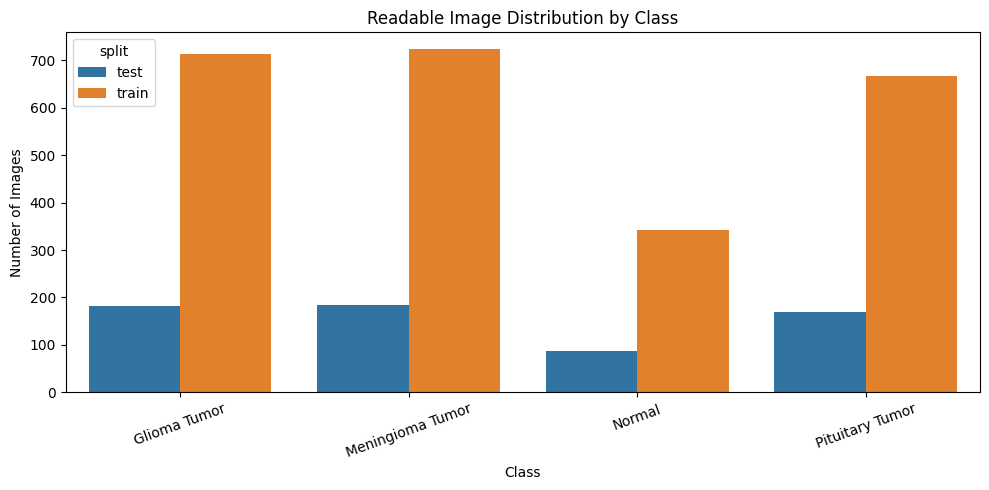

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=class_distribution, x="class_display", y="count", hue="split")
plt.title("Readable Image Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The class distribution is imbalanced. The normal class has fewer samples than the tumor classes, so class weights are used during model training to reduce bias toward the majority classes.

How is the dataset split into training and validation sets? Justify your choice.

In [9]:
class_names = sorted(clean_df["class_name"].unique())
class_to_label = {name: idx for idx, name in enumerate(class_names)}
label_to_class = {idx: CLASS_DISPLAY_NAMES.get(name, name) for name, idx in class_to_label.items()}

clean_df["label"] = clean_df["class_name"].map(class_to_label)

train_source_df = clean_df[clean_df["split"] == "train"].copy().reset_index(drop=True)
test_df = clean_df[clean_df["split"] == "test"].copy().reset_index(drop=True)

train_df, val_df = train_test_split(
    train_source_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_source_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Classes:", label_to_class)

Training images: 1957
Validation images: 490
Testing images: 621
Classes: {0: 'Glioma Tumor', 1: 'Meningioma Tumor', 2: 'Normal', 3: 'Pituitary Tumor'}


,final_split,class_display,count
0,test,Glioma Tumor,181
1,test,Meningioma Tumor,183
2,test,Normal,88
3,test,Pituitary Tumor,169
4,train,Glioma Tumor,570
5,train,Meningioma Tumor,578
6,train,Normal,275
7,train,Pituitary Tumor,534
8,validation,Glioma Tumor,143
9,validation,Meningioma Tumor,145


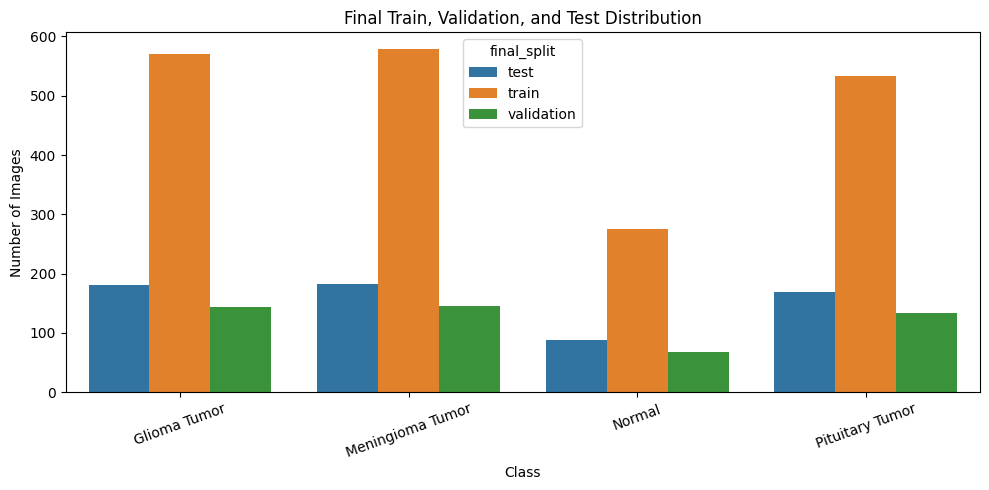

In [10]:
split_table = pd.concat([
    train_df.assign(final_split="train"),
    val_df.assign(final_split="validation"),
    test_df.assign(final_split="test")
])

split_distribution = (
    split_table.groupby(["final_split", "class_display"])
    .size()
    .reset_index(name="count")
)
display(split_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=split_distribution, x="class_display", y="count", hue="final_split")
plt.title("Final Train, Validation, and Test Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The original dataset already provides separate train and test folders. The readable training images are split into 80% training and 20% validation using stratified splitting so that all classes remain represented in both subsets. The test set is kept separate and is used only for final evaluation.

What preprocessing techniques were applied?

In [13]:
def read_resize_normalize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def dataframe_to_dataset(frame, shuffle=False):
    paths = frame["file_path"].values
    labels = frame["label"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(frame),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(read_resize_normalize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

preview_ds = dataframe_to_dataset(train_df, shuffle=False)

for image_batch, label_batch in preview_ds.take(1):
    print("Preprocessing check completed.")
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Minimum pixel value:", tf.reduce_min(image_batch).numpy())
    print("Maximum pixel value:", tf.reduce_max(image_batch).numpy())


I0000 00:00:1778328085.377525      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778328085.383818      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Preprocessing check completed.
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


Images are resized to 224 x 224 pixels so every sample has the same input shape. Pixel values are normalized from 0-255 to 0-1, which improves numerical stability and helps CNN training. Corrupted images are excluded before creating the TensorFlow datasets.

What data generators were used for preprocessing and augmentation?

In [14]:
class SmallGaussianNoise(layers.Layer):
    def __init__(self, stddev=0.01, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=False):
        if training:
            noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev, dtype=inputs.dtype)
            return tf.clip_by_value(inputs + noise, 0.0, 1.0)
        return inputs

augmentation_layer = keras.Sequential([
    layers.RandomRotation(0.03, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, seed=SEED),
    layers.RandomBrightness(factor=0.10, seed=SEED),
    layers.RandomContrast(factor=0.10, seed=SEED),
    SmallGaussianNoise(0.01),
], name="proposal_aligned_augmentation")

def add_training_augmentation(image, label):
    return augmentation_layer(image, training=True), label

train_ds_plain = dataframe_to_dataset(train_df, shuffle=True)
train_ds = train_ds_plain.map(add_training_augmentation, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = dataframe_to_dataset(val_df, shuffle=False)
test_ds = dataframe_to_dataset(test_df, shuffle=False)

A TensorFlow tf.data pipeline is used for loading, resizing, batching, and prefetching images. Augmentation is applied only to training images. The augmentation follows the proposal: small rotation, zoom up to 10%, width/height shifting up to 5%, brightness/contrast adjustment around 10%, and very low Gaussian noise.

Data augmentation was applied, and here are the samples of augmented images:

Selected image: /kaggle/input/datasets/aakritirimal/brain-tumor-classification/Brain Tumor Classifcation/train/glioma_tumor/G_865.jpg
Class: Glioma Tumor


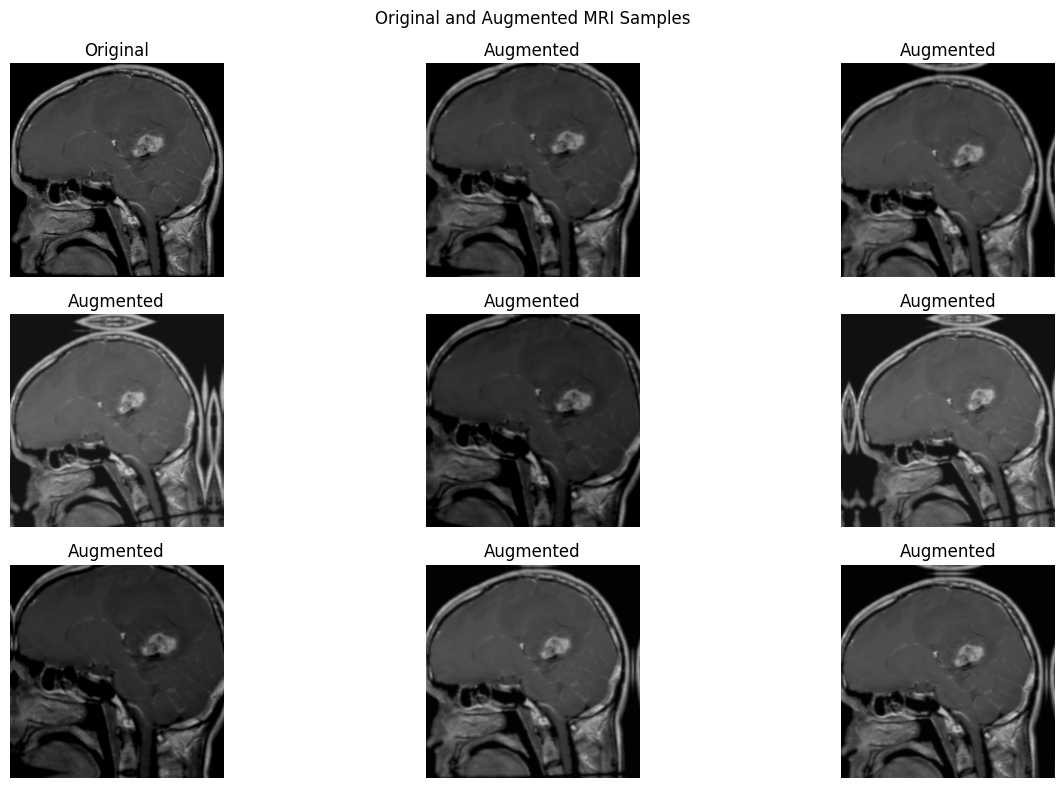

In [18]:
visual_augmentation_layer = keras.Sequential([
    layers.RandomRotation(0.03, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, seed=SEED),
    layers.RandomBrightness(factor=0.10, value_range=(0, 1), seed=SEED),
    layers.RandomContrast(factor=0.10, seed=SEED),
], name="visual_augmentation_layer")


sample_row = train_df.sample(1, random_state=SEED).iloc[0]

print("Selected image:", sample_row["file_path"])
print("Class:", sample_row["class_display"])

sample_image, _ = read_resize_normalize(sample_row["file_path"], sample_row["label"])

plt.figure(figsize=(14, 8))

plt.subplot(3, 3, 1)
plt.imshow(tf.clip_by_value(sample_image, 0, 1))
plt.title("Original")
plt.axis("off")

for i in range(8):
    augmented_image = visual_augmentation_layer(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )[0]

    augmented_image = tf.clip_by_value(augmented_image, 0, 1)

    plt.subplot(3, 3, i + 2)
    plt.imshow(augmented_image)
    plt.title("Augmented")
    plt.axis("off")

plt.suptitle("Original and Augmented MRI Samples")
plt.tight_layout()
plt.show()


The augmented samples show small changes in position, brightness, contrast, zoom, and noise. These changes increase training variation while preserving the important tumor structure in the MRI image.

Display sample original images from each class:

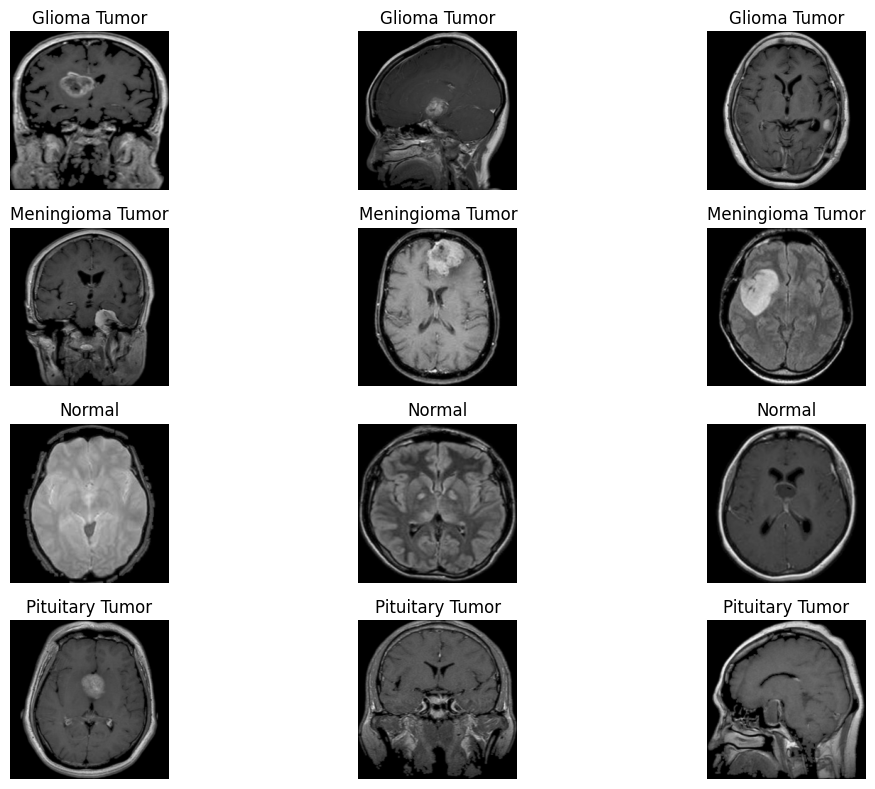

In [19]:
plt.figure(figsize=(12, 8))
plot_number = 1
for class_name in class_names:
    class_samples = train_df[train_df["class_name"] == class_name].sample(3, random_state=SEED)
    for _, row in class_samples.iterrows():
        img = Image.open(row["file_path"]).resize(IMG_SIZE)
        plt.subplot(len(class_names), 3, plot_number)
        plt.imshow(img)
        plt.title(row["class_display"])
        plt.axis("off")
        plot_number += 1
plt.tight_layout()
plt.show()

2.5.2 Design, Train, and Evaluate a Baseline Model

Model Architecture

In [26]:
def create_baseline_model(input_shape=(224, 224, 3), output_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(output_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = create_baseline_model(
    input_shape=(224, 224, 3),
    output_classes=len(class_names)
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,028 (98.51 MB)

 Trainable params: 25,825,028 (98.51 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN has three convolutional layers, each followed by max pooling. The convolution layers use 3 x 3 kernels with 32, 64, and 128 filters. ReLU activation is used in hidden layers, and the output layer uses softmax for four-class classification. The model uses three fully connected layers after feature extraction.

Model Training

In [27]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(train_df["label"].unique())),
    y=train_df["label"].values
)
class_weights = {i: float(w) for i, w in enumerate(weights)}
print("Class weights:", class_weights)

Class weights: {0: 0.8583333333333333, 1: 0.8464532871972318, 2: 1.779090909090909, 3: 0.9161985018726592}


In [28]:
def train_with_timer(model, train_data, valid_data, epochs, model_label, class_weight=None):
    start = time.time()
    history = model.fit(
        train_data,
        validation_data=valid_data,
        epochs=epochs,
        class_weight=class_weight,
        verbose=1
    )
    elapsed = time.time() - start
    print(f"{model_label} training time: {elapsed:.2f} seconds")
    return history, elapsed

baseline_history, baseline_time = train_with_timer(
    baseline_model,
    train_ds_plain,
    val_ds,
    epochs=15,
    model_label="Baseline CNN",
    class_weight=class_weights
)


Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.3377 - loss: 1.5347 - val_accuracy: 0.4449 - val_loss: 1.2153
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.6122 - loss: 0.9102 - val_accuracy: 0.6633 - val_loss: 0.8524
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7678 - loss: 0.5167 - val_accuracy: 0.7041 - val_loss: 0.8105
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.8617 - loss: 0.3282 - val_accuracy: 0.6653 - val_loss: 1.1437
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9216 - loss: 0.1986 - val_accuracy: 0.7673 - val_loss: 0.9824
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9126 - loss: 0.2362 - val_accuracy: 0.7918 - val_loss: 1.0513
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9677 - loss: 0.0762 - val_accuracy: 0.7939 - val_loss: 0.9967
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9926 - loss: 0.0217 - val_accuracy: 0.8061 -

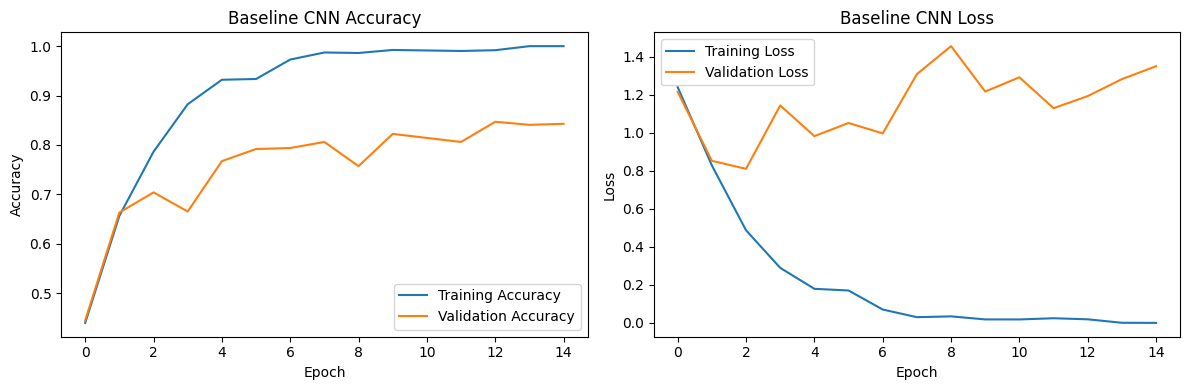

In [29]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")

The baseline CNN learned effectively, with training accuracy increasing close to 100% and validation accuracy reaching around 84%. However, the gap between training and validation accuracy and the increase in validation loss show signs of overfitting.

Model Evaluation

Baseline CNN Classification Report
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.79      0.82       181
Meningioma Tumor       0.76      0.80      0.78       183
          Normal       0.87      0.81      0.84        88
 Pituitary Tumor       0.85      0.91      0.88       169

        accuracy                           0.83       621
       macro avg       0.83      0.83      0.83       621
    weighted avg       0.83      0.83      0.83       621



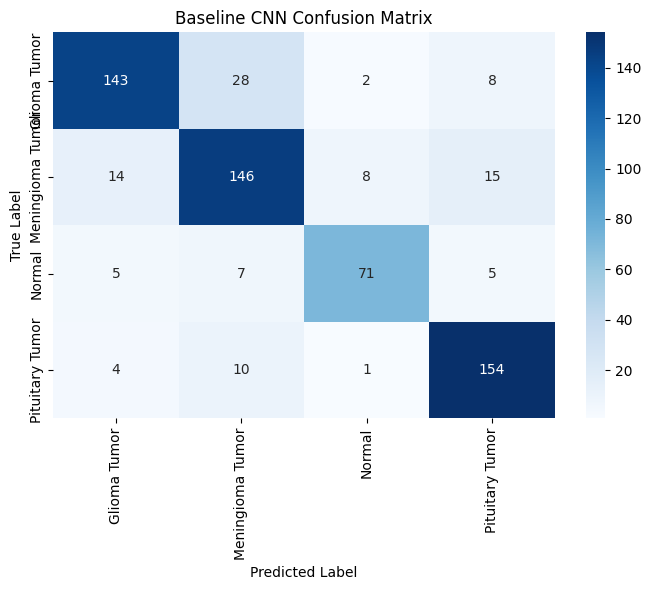

In [30]:
target_names = [label_to_class[i] for i in range(len(label_to_class))]

def predict_dataset(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(probs, axis=1))
    return np.array(y_true), np.array(y_pred)

def evaluate_and_store(model, dataset, model_name, training_time, results_list):
    y_true, y_pred = predict_dataset(model, dataset)
    print(f"{model_name} Classification Report")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": training_time,
    }
    results_list.append(row)
    return y_true, y_pred, row

all_results = []
baseline_y_true, baseline_y_pred, baseline_metrics = evaluate_and_store(
    baseline_model, test_ds, "Baseline CNN", baseline_time, all_results
)

Inference on Sample Images

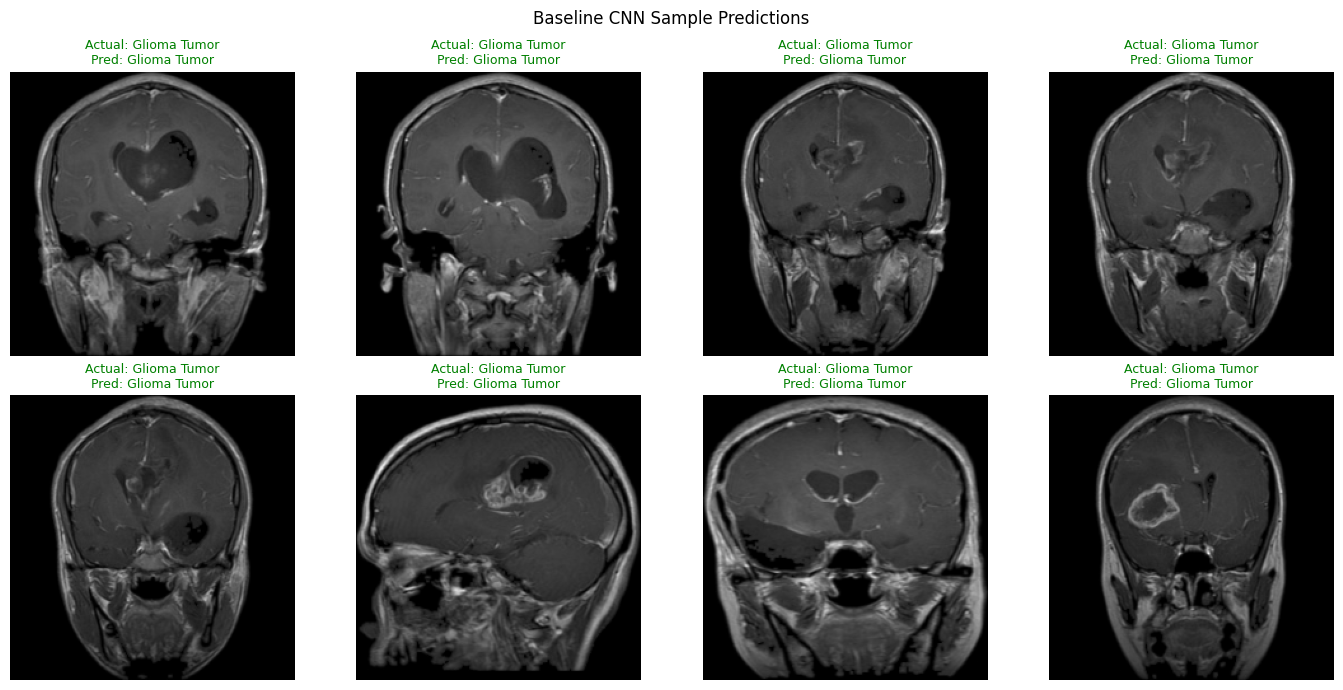

In [31]:
def show_predictions(model, dataset, title, count=8):
    for images, labels in dataset.take(1):
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        plt.figure(figsize=(14, 7))
        for i in range(min(count, len(images))):
            actual = label_to_class[int(labels[i])]
            predicted = label_to_class[int(preds[i])]
            color = "green" if actual == predicted else "red"
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i])
            plt.title(f"Actual: {actual}\nPred: {predicted}", color=color, fontsize=9)
            plt.axis("off")
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()
        break

show_predictions(baseline_model, test_ds, "Baseline CNN Sample Predictions")

Key observations about model performance:
The baseline CNN performed well as an initial model and correctly predicted the sample glioma tumor images shown. This indicates that the model learned relevant MRI image features. However, the training accuracy was higher than the validation accuracy, and validation loss increased in later epochs, showing signs of overfitting. Therefore, deeper models with regularization and augmentation were explored to improve generalization.


2.5.3 Deeper Architecture with Regularization Layer

Model Architecture

In [40]:
reduced_class_weights = {
    class_id: 1.0 + (weight - 1.0) * 0.5
    for class_id, weight in class_weights.items()
}

print("Original class weights:", class_weights)
print("Reduced class weights:", reduced_class_weights)


Original class weights: {0: 0.8583333333333333, 1: 0.8464532871972318, 2: 1.779090909090909, 3: 0.9161985018726592}
Reduced class weights: {0: 0.9291666666666667, 1: 0.9232266435986158, 2: 1.3895454545454546, 3: 0.9580992509363295}


In [41]:
def create_deeper_model(input_shape=(224, 224, 3), output_classes=4, optimizer="adam", include_dropout=True):
    block_dropout = [0.10, 0.15, 0.20]
    model = keras.Sequential(name=f"deeper_cnn_{optimizer}_dropout_{include_dropout}")
    model.add(layers.Input(shape=input_shape))

    for index, filters in enumerate([32, 64, 128]):
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(layers.MaxPooling2D((2, 2)))
        if include_dropout:
            model.add(layers.Dropout(block_dropout[index]))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation="relu"))
    if include_dropout:
        model.add(layers.Dropout(0.25))
    model.add(layers.Dense(128, activation="relu"))
    if include_dropout:
        model.add(layers.Dropout(0.15))
    model.add(layers.Dense(output_classes, activation="softmax"))

    if optimizer == "sgd":
        opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    else:
        opt = keras.optimizers.Adam(learning_rate=0.0005)

    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

deeper_adam_model = create_deeper_model(output_classes=len(class_names), optimizer="adam", include_dropout=True)

The deeper CNN doubles the convolutional depth of the baseline model by using six convolutional layers. Batch normalization is added to stabilize training, and dropout is added as a regularization technique. The dropout values are kept moderate so the model can still learn useful features.

Model Training:

Model: "deeper_cnn_adam_dropout_True"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,340 (1.35 MB)

 Trainable params: 353,892 (1.35 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 281ms/step - accuracy: 0.4033 - loss: 1.2595 - val_accuracy: 0.2918 - val_loss: 1.4353
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.6184 - loss: 0.9165 - val_accuracy: 0.2918 - val_loss: 1.5715
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.6733 - loss: 0.7381 - val_accuracy: 0.2918 - val_loss: 2.2961
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.7362 - loss: 0.6475 - val_accuracy: 0.2735 - val_loss: 3.1538
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.7476 - loss: 0.6188 - val_accuracy: 0.2735 - val_loss: 4.4568
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.7804 - loss: 0.5471 - val_accuracy: 0.3122 - val_loss: 2.7271
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.7779 - loss: 0.5357 - val_accuracy: 0.4102 - val_loss: 2.3567
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.7906 - loss: 0.4998 - val_accuracy: 

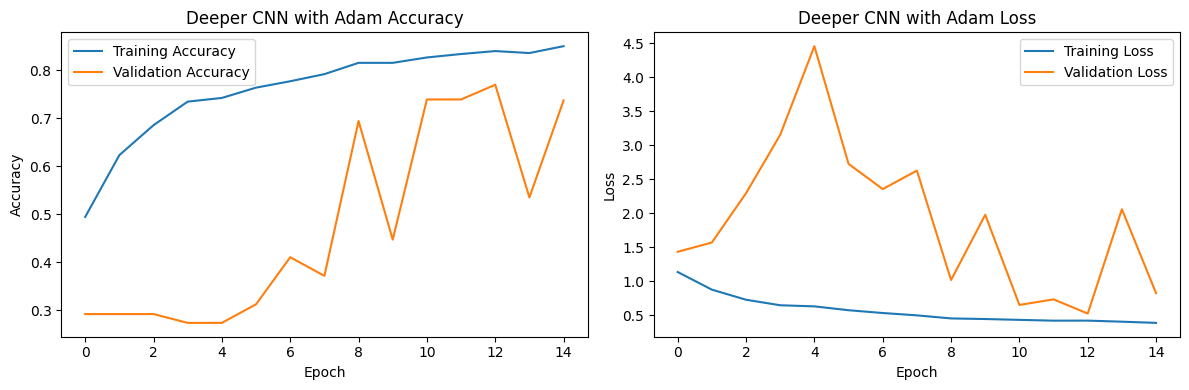

In [42]:
deeper_adam_model = create_deeper_model(
    output_classes=len(class_names),
    optimizer="adam",
    include_dropout=True
)

deeper_adam_model.summary()

deeper_adam_history, deeper_adam_time = train_with_timer(
    deeper_adam_model,
    train_ds_plain,
    val_ds,
    EPOCHS,
    "Deeper CNN with Adam",
    reduced_class_weights
)

plot_history(deeper_adam_history, "Deeper CNN with Adam")


The deeper CNN with Adam showed stronger learning after removing class weights. Training accuracy increased steadily to around 86%, while validation accuracy improved to around 76%. Validation loss was unstable in earlier epochs but decreased toward the final epochs, suggesting that the model gradually learned more general features. 

Model Evaluation

Deeper CNN Adam Classification Report
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.54      0.66       181
Meningioma Tumor       0.75      0.60      0.67       183
          Normal       0.55      0.94      0.69        88
 Pituitary Tumor       0.76      0.95      0.84       169

        accuracy                           0.72       621
       macro avg       0.73      0.76      0.72       621
    weighted avg       0.76      0.72      0.72       621



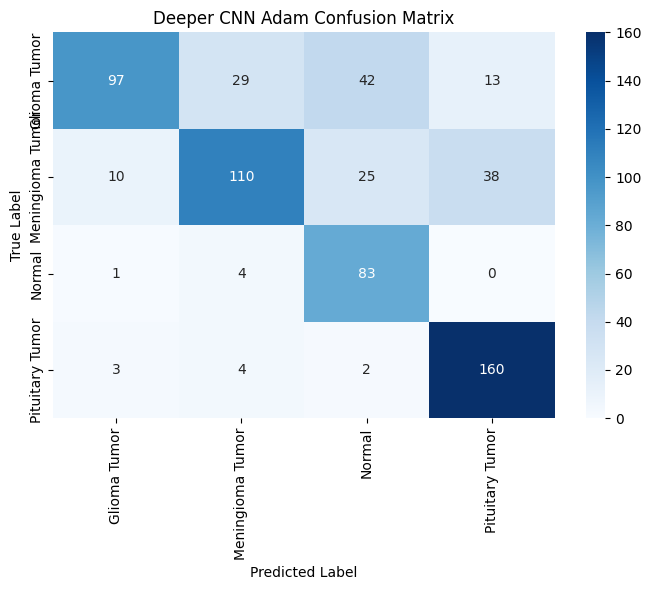

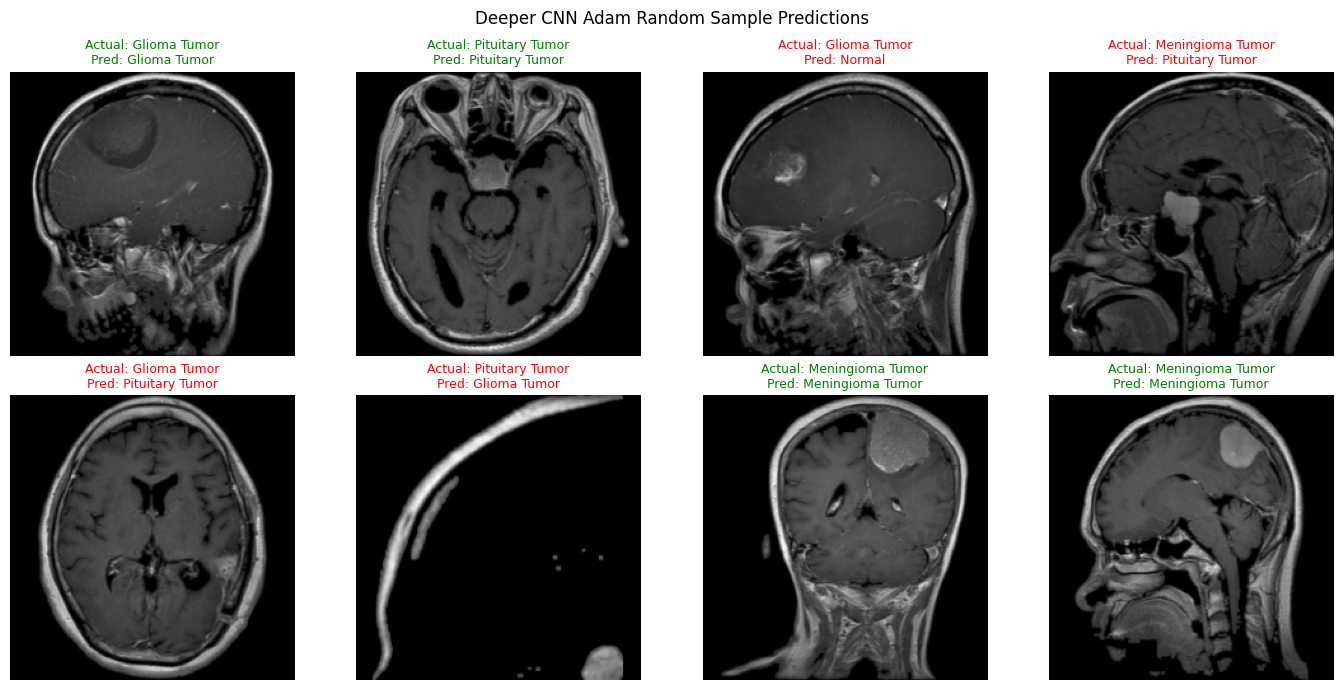

In [43]:
deeper_adam_y_true, deeper_adam_y_pred, deeper_adam_metrics = evaluate_and_store(
    deeper_adam_model,
    test_ds,
    "Deeper CNN Adam",
    deeper_adam_time,
    all_results
)

show_random_predictions(
    deeper_adam_model,
    test_df,
    "Deeper CNN Adam Random Sample Predictions"
)


The random sample predictions show that the deeper CNN with Adam can correctly identify some glioma, pituitary, and meningioma images. However, several misclassifications are also visible, especially between tumor classes.

2.5.4 Experimentation and Comparative Analysis

Baseline vs. Deeper Model Performance

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Baseline CNN,0.827697,0.82931,0.827697,0.827473,65.115384
2,Deeper CNN Adam,0.724638,0.75896,0.724638,0.717288,155.355146


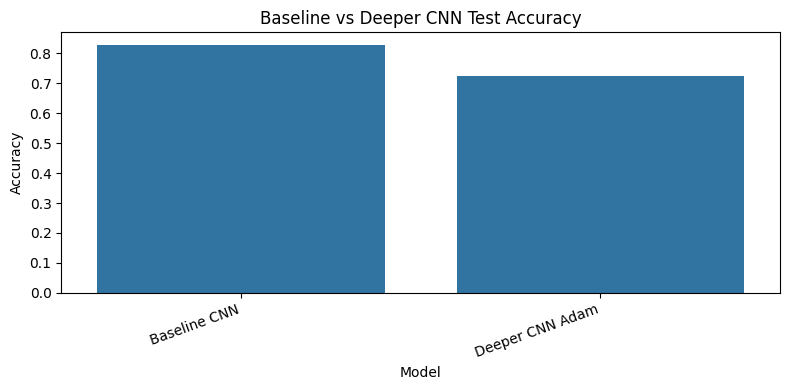

In [47]:
scratch_comparison = pd.DataFrame(all_results)

scratch_comparison = scratch_comparison.drop_duplicates(
    subset=["Model"],
    keep="last"
)

display(scratch_comparison)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=scratch_comparison,
    x="Model",
    y="Accuracy"
)
plt.title("Baseline vs Deeper CNN Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


This comparison shows whether increasing the number of convolutional layers improved performance. The decision should be based on test accuracy, weighted F1-score, and the training/validation loss curves rather than accuracy alone.

Computational Efficiency

In [48]:
time_comparison = pd.DataFrame([
    {"Model": "Baseline CNN", "Training Time (s)": baseline_time},
    {"Model": "Deeper CNN Adam", "Training Time (s)": deeper_adam_time},
])
display(time_comparison)

,Model,Training Time (s)
0,Baseline CNN,65.115384
1,Deeper CNN Adam,155.355146


The baseline CNN is expected to train faster because it has fewer layers and fewer trainable operations. The deeper CNN may improve accuracy, but it usually requires more computation. This shows the trade-off between model complexity and efficiency.

Optimizer Analysis: SGD vs Adam

In [51]:
def create_deeper_sgd_model(input_shape=(224, 224, 3), output_classes=4, include_dropout=True):
    block_dropout = [0.10, 0.15, 0.20]

    model = keras.Sequential(name="deeper_cnn_sgd_tuned")
    model.add(layers.Input(shape=input_shape))

    for index, filters in enumerate([32, 64, 128]):
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        model.add(layers.MaxPooling2D((2, 2)))

        if include_dropout:
            model.add(layers.Dropout(block_dropout[index]))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation="relu"))

    if include_dropout:
        model.add(layers.Dropout(0.25))

    model.add(layers.Dense(128, activation="relu"))

    if include_dropout:
        model.add(layers.Dropout(0.15))

    model.add(layers.Dense(output_classes, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


Model: "deeper_cnn_sgd_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,340 (1.35 MB)

 Trainable params: 353,892 (1.35 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 271ms/step - accuracy: 0.3084 - loss: 1.4664 - val_accuracy: 0.2918 - val_loss: 1.3593
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.4389 - loss: 1.2254 - val_accuracy: 0.2918 - val_loss: 1.3743
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.5128 - loss: 1.1429 - val_accuracy: 0.2918 - val_loss: 1.4853
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5356 - loss: 1.0684 - val_accuracy: 0.2918 - val_loss: 1.6102
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.5488 - loss: 1.0510 - val_accuracy: 0.2959 - val_loss: 1.7812
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.5504 - loss: 1.0357 - val_accuracy: 0.2959 - val_loss: 1.8339
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.5614 - loss: 1.0134 - val_accuracy: 0.2959 - val_loss: 1.8424
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.5990 - loss: 0.9367 - val_accuracy: 

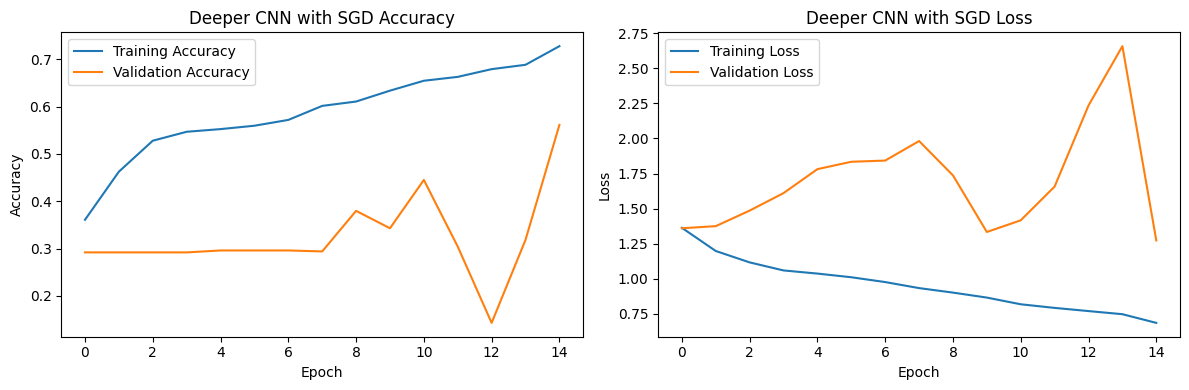

Deeper CNN SGD Classification Report
                  precision    recall  f1-score   support

    Glioma Tumor       0.47      0.91      0.62       181
Meningioma Tumor       0.47      0.11      0.18       183
          Normal       0.73      0.22      0.33        88
 Pituitary Tumor       0.71      0.83      0.77       169

        accuracy                           0.56       621
       macro avg       0.59      0.52      0.48       621
    weighted avg       0.57      0.56      0.49       621



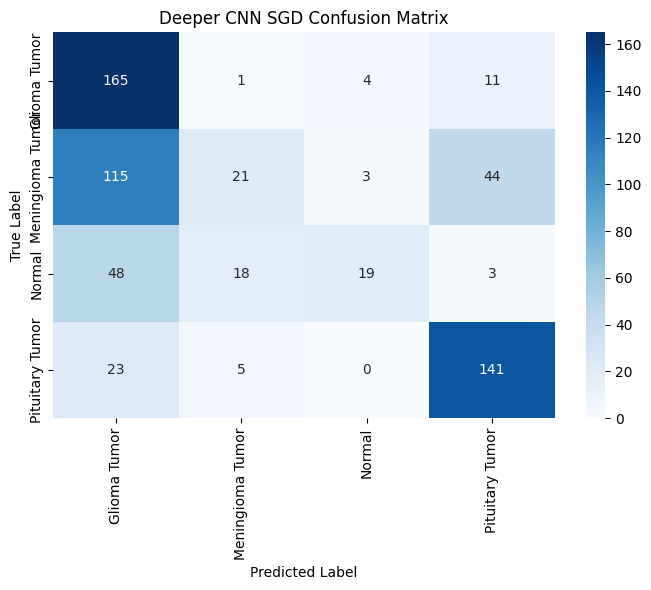

In [52]:
deeper_sgd_model = create_deeper_sgd_model(
    output_classes=len(class_names),
    include_dropout=True
)

deeper_sgd_model.summary()

deeper_sgd_history, deeper_sgd_time = train_with_timer(
    deeper_sgd_model,
    train_ds_plain,
    val_ds,
    EPOCHS,
    "Deeper CNN with SGD",
    None
)

plot_history(deeper_sgd_history, "Deeper CNN with SGD")

deeper_sgd_y_true, deeper_sgd_y_pred, deeper_sgd_metrics = evaluate_and_store(
    deeper_sgd_model,
    test_ds,
    "Deeper CNN SGD",
    deeper_sgd_time,
    all_results
)


,Optimizer,Final Validation Accuracy,Test Accuracy,Training Time (s)
0,Adam,0.736735,0.724638,155.355146
1,SGD,0.561224,0.557166,153.962279


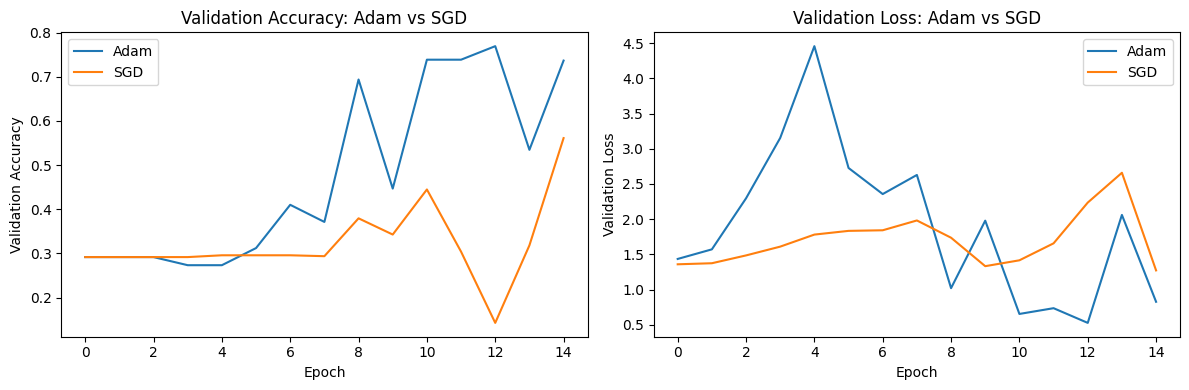

In [53]:
optimizer_table = pd.DataFrame([
    {
        "Optimizer": "Adam",
        "Final Validation Accuracy": deeper_adam_history.history["val_accuracy"][-1],
        "Test Accuracy": deeper_adam_metrics["Accuracy"],
        "Training Time (s)": deeper_adam_time,
    },
    {
        "Optimizer": "SGD",
        "Final Validation Accuracy": deeper_sgd_history.history["val_accuracy"][-1],
        "Test Accuracy": deeper_sgd_metrics["Accuracy"],
        "Training Time (s)": deeper_sgd_time,
    },
])
display(optimizer_table)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(deeper_adam_history.history["val_accuracy"], label="Adam")
plt.plot(deeper_sgd_history.history["val_accuracy"], label="SGD")
plt.title("Validation Accuracy: Adam vs SGD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deeper_adam_history.history["val_loss"], label="Adam")
plt.plot(deeper_sgd_history.history["val_loss"], label="SGD")
plt.title("Validation Loss: Adam vs SGD")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

After tuning SGD with a lower learning rate, the deeper CNN improved compared with the first SGD attempt. Training accuracy increased steadily and validation accuracy reached around 56%. However, validation loss remained unstable, showing that SGD did not generalize as well as Adam for this dataset. Therefore, Adam was more effective for the deeper CNN architecture.


Ablation Study

Model: "deeper_cnn_adam_dropout_False"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,340 (1.35 MB)

 Trainable params: 353,892 (1.35 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.5435 - loss: 1.0939 - val_accuracy: 0.2918 - val_loss: 1.5341
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.6572 - loss: 0.8356 - val_accuracy: 0.2918 - val_loss: 2.1948
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.7340 - loss: 0.6436 - val_accuracy: 0.2918 - val_loss: 2.9725
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.7345 - loss: 0.6392 - val_accuracy: 0.3449 - val_loss: 1.6768
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.7794 - loss: 0.5525 - val_accuracy: 0.3265 - val_loss: 1.5136
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.7993 - loss: 0.4582 - val_accuracy: 0.3000 - val_loss: 1.6647
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.8115 - loss: 0.4759 - val_accuracy: 0.3265 - val_loss: 1.3921
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.8063 - loss: 0.4468 - val_accuracy: 

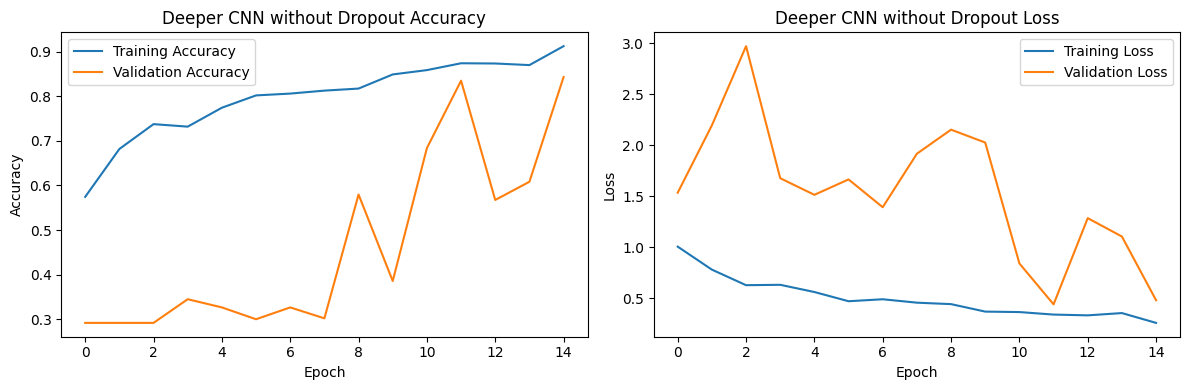

Ablation: No Dropout Classification Report
                  precision    recall  f1-score   support

    Glioma Tumor       0.77      0.84      0.80       181
Meningioma Tumor       0.80      0.60      0.68       183
          Normal       0.88      0.81      0.84        88
 Pituitary Tumor       0.80      0.97      0.87       169

        accuracy                           0.80       621
       macro avg       0.81      0.80      0.80       621
    weighted avg       0.80      0.80      0.79       621



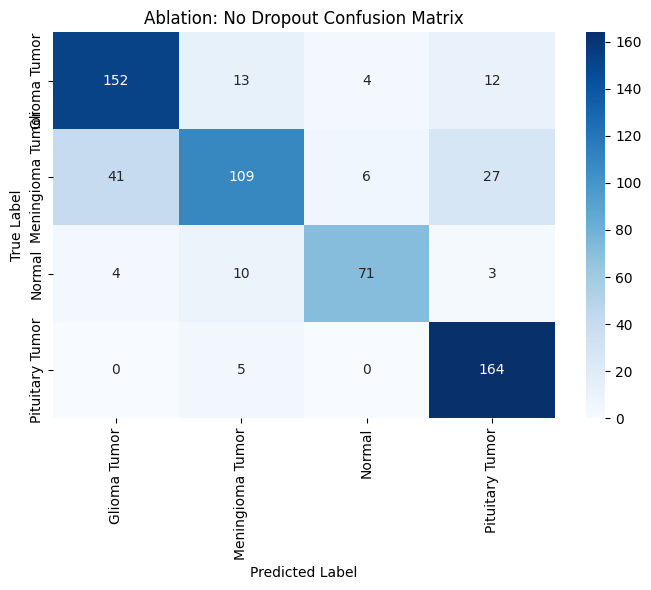

In [55]:
no_dropout_model = create_deeper_model(
    output_classes=len(class_names),
    optimizer="adam",
    include_dropout=False
)

no_dropout_model.summary()

no_dropout_history, no_dropout_time = train_with_timer(
    no_dropout_model,
    train_ds_plain,
    val_ds,
    EPOCHS,
    "Deeper CNN without Dropout",
    None
)

plot_history(no_dropout_history, "Deeper CNN without Dropout")

no_dropout_y_true, no_dropout_y_pred, no_dropout_metrics = evaluate_and_store(
    no_dropout_model,
    test_ds,
    "Ablation: No Dropout",
    no_dropout_time,
    all_results
)


In [56]:
ablation_table = pd.DataFrame([
    {
        "Model": "With Dropout",
        "Final Validation Accuracy": deeper_adam_history.history["val_accuracy"][-1],
        "Test Accuracy": deeper_adam_metrics["Accuracy"],
        "Weighted F1": deeper_adam_metrics["F1 Score"],
    },
    {
        "Model": "Without Dropout",
        "Final Validation Accuracy": no_dropout_history.history["val_accuracy"][-1],
        "Test Accuracy": no_dropout_metrics["Accuracy"],
        "Weighted F1": no_dropout_metrics["F1 Score"],
    },
])
display(ablation_table)

,Model,Final Validation Accuracy,Test Accuracy,Weighted F1
0,With Dropout,0.736735,0.724638,0.717288
1,Without Dropout,0.842857,0.798712,0.792261


This ablation study removes dropout from the deeper CNN. If performance improves, dropout may have been too restrictive for this dataset. If performance decreases or validation loss becomes unstable, dropout helped regularization.

Challenges and Observations

The main challenges are corrupted images, class imbalance, overfitting risk, and visual similarity between tumor types. Corrupted files are removed before training. Class weights are used because the normal class has fewer examples. Hardware acceleration should be enabled in Kaggle using GPU to reduce training time.

2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

2.6.1 Loading and Adapting a Pre-Trained Model

In [61]:
def mobilenet_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def mobilenet_dataset(frame, shuffle=False):
    paths = frame["file_path"].values
    labels = frame["label"].astype("int32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_mobilenet_ds = mobilenet_dataset(train_df, shuffle=True)
val_mobilenet_ds = mobilenet_dataset(val_df, shuffle=False)
test_mobilenet_ds = mobilenet_dataset(test_df, shuffle=False)

In [62]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.25),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
], name="mobilenetv2_feature_extractor")

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 is selected because it is lightweight and already trained on ImageNet. The original 1000-class classification head is removed using include_top=False, and a new classification head is added for the four MRI classes. The convolutional base is frozen first so the model works as a feature extractor.

2.6.2 Model Training and Fine-Tuning

Epoch 1/15


2026-05-09 14:21:06.721419: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:21:06.860111: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5505 - loss: 1.0772

2026-05-09 14:21:19.432964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:21:19.569800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5527 - loss: 1.0720

2026-05-09 14:21:34.610532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:21:34.762945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:21:34.900146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 451ms/step - accuracy: 0.5547 - loss: 1.0669 - val_accuracy: 0.7980 - val_loss: 0.5513
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8184 - loss: 0.4447 - val_accuracy: 0.8163 - val_loss: 0.4920
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8350 - loss: 0.3806 - val_accuracy: 0.8000 - val_loss: 0.4841
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8557 - loss: 0.3359 - val_accuracy: 0.8408 - val_loss: 0.4574
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8590 - loss: 0.2979 - val_accuracy: 0.8306 - val_loss: 0.4355
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8921 - loss: 0.2489 - val_accuracy: 0.8184 - val_loss: 0.5256
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9085 - loss: 0.2213 - val_accuracy: 0.8469 - val_loss: 0.4641
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8854 - loss: 0.2809 - val_accuracy: 0.8531 - val_loss: 

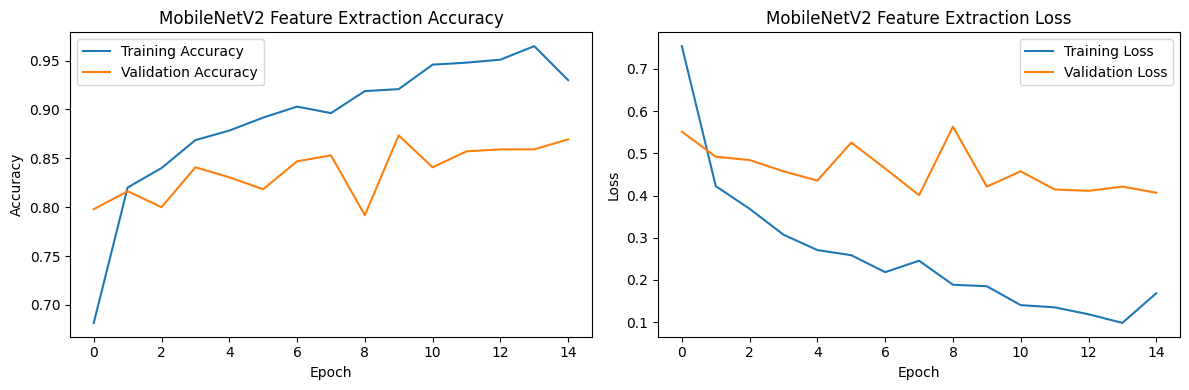

2026-05-09 14:22:23.977147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:22:24.114847: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


MobileNetV2 Feature Extraction Classification Report
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.83      0.85       181
Meningioma Tumor       0.81      0.86      0.83       183
          Normal       0.93      0.93      0.93        88
 Pituitary Tumor       0.94      0.93      0.93       169

        accuracy                           0.88       621
       macro avg       0.89      0.89      0.89       621
    weighted avg       0.88      0.88      0.88       621



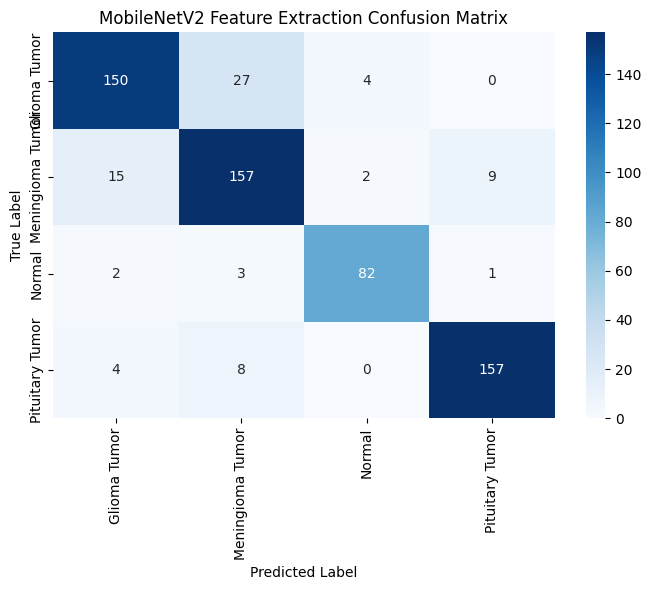

In [63]:
transfer_history, transfer_time = train_with_timer(
    transfer_model, train_mobilenet_ds, val_mobilenet_ds, EPOCHS, "MobileNetV2 Feature Extraction", class_weights
)
plot_history(transfer_history, "MobileNetV2 Feature Extraction")

transfer_y_true, transfer_y_pred, transfer_metrics = evaluate_and_store(
    transfer_model, test_mobilenet_ds, "MobileNetV2 Feature Extraction", transfer_time, all_results
)

In feature extraction, the MobileNetV2 base remains frozen and only the new dense classification layers are trained. This reduces training time and uses general visual features learned from ImageNet.

Fine-Tuning MobileNetV2

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 269ms/step - accuracy: 0.7669 - loss: 0.6268 - val_accuracy: 0.8612 - val_loss: 0.4453
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8195 - loss: 0.3773 - val_accuracy: 0.8571 - val_loss: 0.4586
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8550 - loss: 0.3422 - val_accuracy: 0.8551 - val_loss: 0.4982
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8816 - loss: 0.2647 - val_accuracy: 0.8531 - val_loss: 0.5135
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9010 - loss: 0.2230 - val_accuracy: 0.8551 - val_loss: 0.5176
Fine-Tuned MobileNetV2 training time: 42.62 seconds


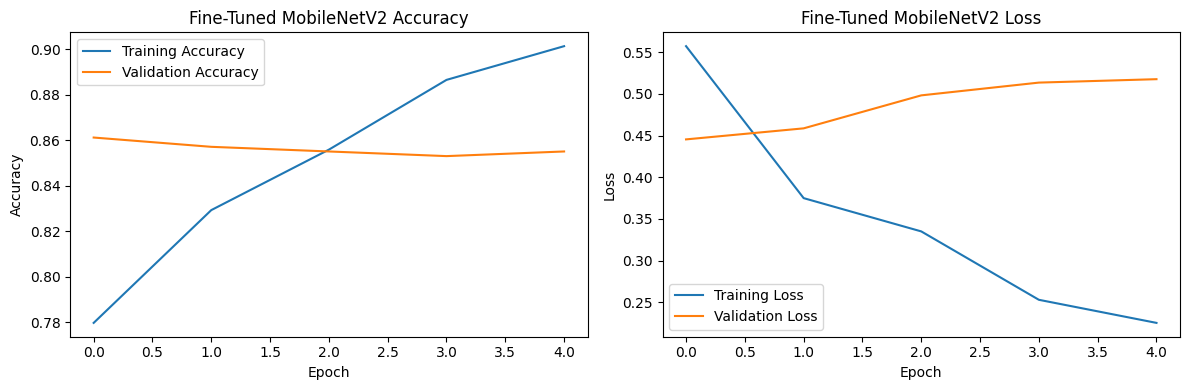

In [64]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history, fine_tune_time = train_with_timer(
    transfer_model, train_mobilenet_ds, val_mobilenet_ds, 5, "Fine-Tuned MobileNetV2", class_weights
)
plot_history(fine_tune_history, "Fine-Tuned MobileNetV2")

During fine-tuning, only the top MobileNetV2 layers are unfrozen and trained using a very low learning rate. This helps the pre-trained model adjust to the MRI dataset while reducing the risk of catastrophic forgetting.

2.6.3 Model Evaluation and Prediction

Fine-Tuned MobileNetV2 Classification Report
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.89      0.88       181
Meningioma Tumor       0.87      0.69      0.77       183
          Normal       0.83      0.97      0.89        88
 Pituitary Tumor       0.87      0.96      0.91       169

        accuracy                           0.86       621
       macro avg       0.86      0.88      0.86       621
    weighted avg       0.86      0.86      0.86       621



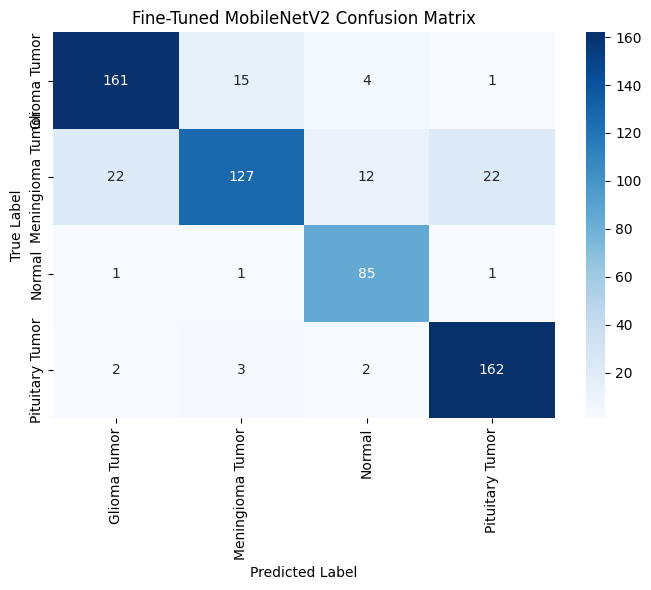

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8188858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.75393856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.87830627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.74161875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6408948].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.90808344].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.85930455].
Clipping input data to

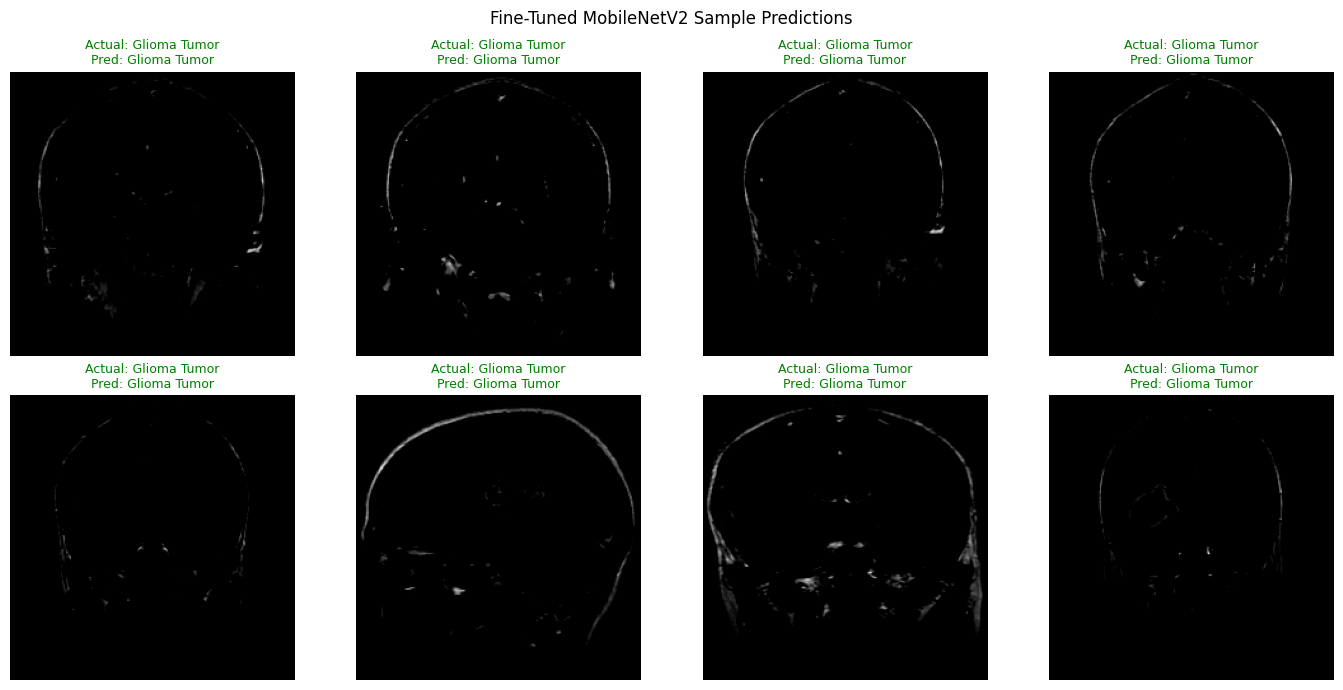

In [65]:
fine_tune_y_true, fine_tune_y_pred, fine_tune_metrics = evaluate_and_store(
    transfer_model, test_mobilenet_ds, "Fine-Tuned MobileNetV2", transfer_time + fine_tune_time, all_results
)

show_predictions(transfer_model, test_mobilenet_ds, "Fine-Tuned MobileNetV2 Sample Predictions")

Final Model Comparison

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,MobileNetV2 Feature Extraction,0.879227,0.880822,0.879227,0.879568,75.201650
1,Fine-Tuned MobileNetV2,0.861514,0.862596,0.861514,0.857739,117.820675
2,Baseline CNN,0.827697,0.829310,0.827697,0.827473,65.115384
3,Ablation: No Dropout,0.798712,0.800214,0.798712,0.792261,147.225841
4,Deeper CNN Adam,0.724638,0.758960,0.724638,0.717288,155.355146
5,Deeper CNN SGD,0.557166,0.570913,0.557166,0.490859,153.962279


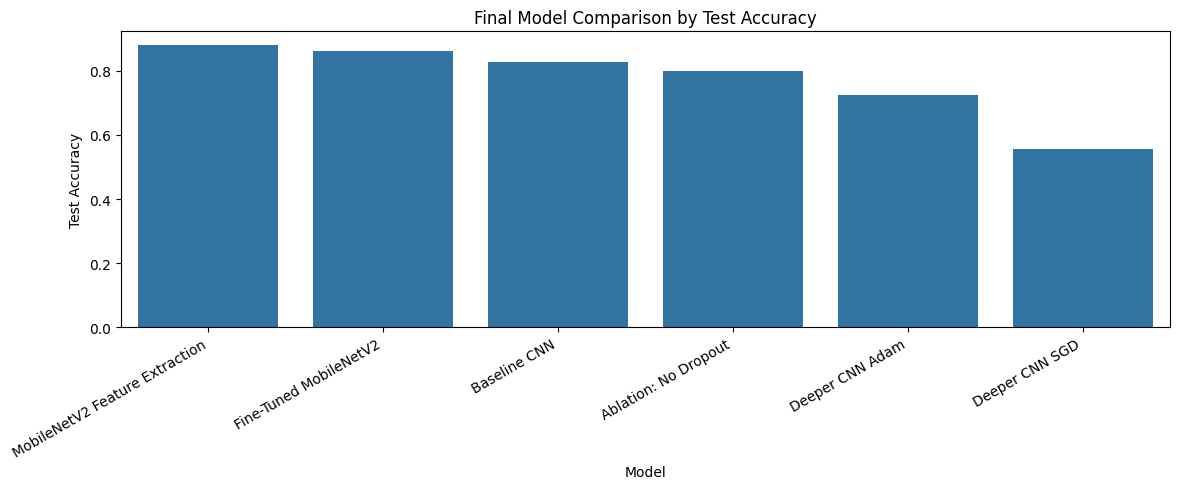

In [66]:
final_results = pd.DataFrame(all_results).drop_duplicates(subset=["Model"], keep="last")
final_results = final_results.sort_values(["F1 Score", "Accuracy"], ascending=False).reset_index(drop=True)
display(final_results)

plt.figure(figsize=(12, 5))
sns.barplot(data=final_results, x="Model", y="Accuracy")
plt.title("Final Model Comparison by Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Discuss whether transfer learning outperforms training from scratch


Based on the final model comparison, transfer learning outperformed the CNN models trained from scratch. The MobileNetV2 feature extraction model achieved the highest test accuracy of 87.92% and the highest F1-score of 87.96%. This was better than the baseline CNN, which achieved 82.77% accuracy and 82.75% F1-score. It was also better than the deeper CNN models trained from scratch.


The fine-tuned MobileNetV2 model also performed well, achieving 86.15% accuracy and 85.77% F1-score. However, it did not outperform the MobileNetV2 feature extraction model. This suggests that the frozen pre-trained MobileNetV2 features were already effective for this MRI classification task, while fine-tuning introduced slight overfitting or did not provide enough additional benefit.


Overall, transfer learning was more effective than training CNN models from scratch because MobileNetV2 had already learned useful visual features from a large image dataset. This helped the model generalize better to the brain tumor MRI dataset, even with class imbalance and a limited number of images.

Save Trained Models


The trained models are saved so they can be reused later without retraining. This is useful for future testing, deployment, or further analysis.

In [67]:
baseline_model.save("baseline_cnn_model.keras")
deeper_adam_model.save("deeper_cnn_adam_model.keras")
deeper_sgd_model.save("deeper_cnn_sgd_model.keras")
no_dropout_model.save("ablation_no_dropout_model.keras")

transfer_model.save("mobilenetv2_finetuned_model.keras")

print("All selected models saved successfully.")


All selected models saved successfully.


Conclusion


This project implemented an end-to-end brain tumor classification pipeline using MRI images. The dataset was first cleaned by detecting and excluding corrupted images, leaving only readable images for training, validation, and testing. The class distribution showed imbalance, especially because the normal class had fewer images than the tumor classes. Therefore, preprocessing, normalization, augmentation, and class distribution analysis were important steps before model training.

Several models were developed and compared. The baseline CNN achieved 82.77% test accuracy, showing that a simple CNN can learn useful MRI image features. The deeper CNN with Adam achieved 72.46% accuracy, while the deeper CNN with SGD achieved 55.72%, showing that increasing model depth and changing optimizers did not automatically improve performance. The ablation model without dropout achieved 79.87%, which was better than the deeper CNN with dropout but still lower than the baseline CNN.

The best-performing model was MobileNetV2 feature extraction, which achieved 87.92% test accuracy and 87.96% F1-score. Fine-tuned MobileNetV2 also performed strongly with 86.15% accuracy, but it did not improve over feature extraction. Therefore, MobileNetV2 feature extraction was selected as the best model. The results show that transfer learning was effective for this brain tumor classification task because pre-trained features helped improve generalization compared with CNN models trained from scratch.